In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import numpy as np

In [ ]:
VARIABLE = "edv" # "edv", "temp", or "heat_index"

assert VARIABLE in ["edv", "temp", "heat_index"], f"invalid `VARIABLE` value: {VARIABLE}"

INPUT_FILE = f"../data/{VARIABLE}/regional_{VARIABLE}_data.csv"
OUTPUT_FILE = f"../data/{VARIABLE}/{VARIABLE}_seasonality.csv"
PLOT_OUTPUT_FILE = f"../plots/seasonality/{VARIABLE}_seasonality.png"
USE_LN = True

In [77]:
OMEGA = 1/365.25
PHI = 2*np.pi*OMEGA

def f(t, beta_0, beta_s, beta_c):
    if USE_LN:
        return np.exp(beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t))
    else:
        return beta_0 + beta_s*np.sin(PHI*t) + beta_c*np.cos(PHI*t)

In [78]:
df = pd.read_csv(INPUT_FILE, index_col=0)
y_min = df.values.min()
y_max = df.values.max()
y_range = y_max - y_min
df.head()

,Region 1,Region 2,Region 3,Region 4,Region 5,Region 6,Region 7,Region 8,Region 9,Region 10
temporal,,,,,,,,,,
2018-01-01,7,11,7,0,9,0,33,0,0,48
2018-01-02,0,13,10,5,8,0,128,0,0,0
2018-01-03,0,6,4,3,0,5,34,0,11,0
2018-01-04,11,5,0,8,6,0,0,0,16,0
2018-01-05,14,4,4,3,11,0,0,0,5,20


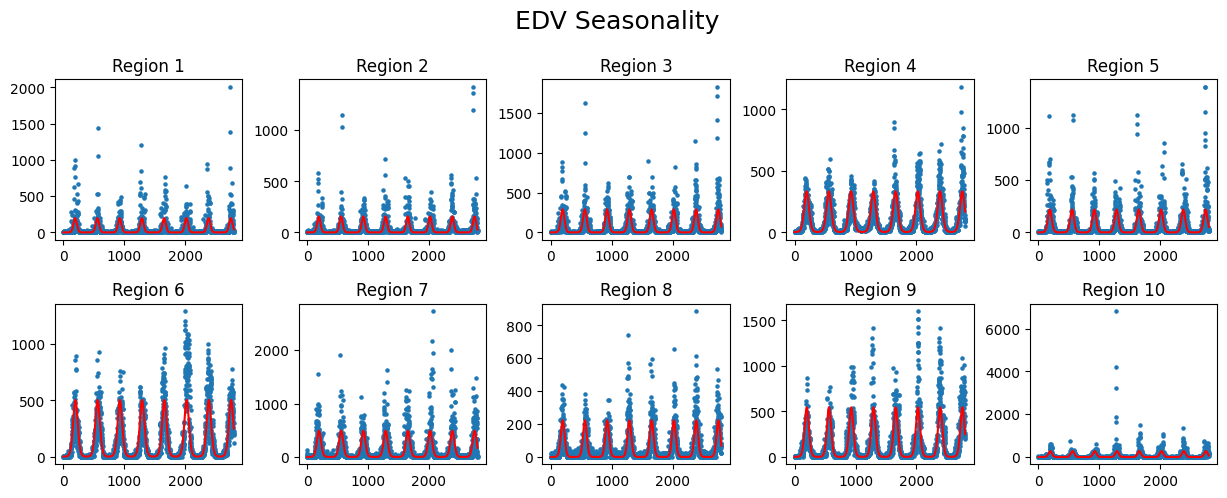

,region,beta_0,beta_s,beta_c,sigma_00,sigma_0s,sigma_0c,sigma_ss,sigma_sc,sigma_cc,psi,var_psi,peak_T,sigma_peak_T,peak_T_CI_lower,peak_T_CI_upper,gamma,var_gamma,theta
0,Region 1,0.709409,-0.812596,-4.501070,0.088772,0.016340,0.091947,0.008853,0.015995,0.096090,0.178610,0.000287,193.007842,0.985595,191.076112,194.939573,4.573832,0.087743,96.914786
1,Region 2,0.188291,-0.765453,-4.801009,0.089060,0.014525,0.092303,0.007855,0.014277,0.096392,0.158105,0.000237,191.815865,0.895635,190.060453,193.571278,4.861647,0.089757,129.236849
2,Region 3,1.725784,-0.662858,-3.883870,0.032450,0.005652,0.033915,0.003568,0.005528,0.035864,0.169041,0.000171,192.451569,0.759295,190.963378,193.939761,3.940029,0.033117,51.420079
3,Region 4,3.517162,-0.536066,-2.228913,0.002655,0.000641,0.002827,0.000604,0.000602,0.003138,0.236023,0.000089,196.345326,0.548770,195.269758,197.420895,2.292470,0.002725,9.899358
4,Region 5,1.908056,-0.284602,-3.468081,0.033053,0.002751,0.035148,0.003392,0.002707,0.037878,0.081880,0.000263,187.384788,0.942180,185.538148,189.231427,3.479739,0.037206,32.451252
5,Region 6,3.730706,-0.635092,-2.409287,0.004150,0.001096,0.004374,0.000899,0.001033,0.004779,0.257739,0.000103,197.607705,0.591182,196.449011,198.766400,2.491587,0.004017,12.080431
6,Region 7,3.081957,-0.576698,-3.060022,0.017584,0.003364,0.018565,0.002547,0.003258,0.019989,0.186277,0.000202,193.453538,0.826367,191.833888,195.073187,3.113891,0.018205,22.508448
7,Region 8,1.768866,-0.711032,-3.567720,0.013174,0.002667,0.013759,0.001691,0.002591,0.014581,0.196718,0.000090,194.060508,0.551308,192.979965,195.141051,3.637883,0.013095,38.011295
8,Region 9,3.381625,-0.800039,-2.806447,0.006963,0.001983,0.007229,0.001363,0.001877,0.007710,0.277706,0.000100,198.768407,0.580933,197.629799,199.907015,2.918254,0.006244,18.508939
9,Region 10,1.112626,-0.975752,-4.399339,0.163925,0.036781,0.168589,0.019072,0.035725,0.175159,0.218262,0.000556,195.312860,1.370469,192.626789,197.998930,4.506249,0.152736,90.581393


In [79]:
fig, axs = plt.subplots(2, 5, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
data = []
for i, region in enumerate(df.columns):
    x = np.arange(len(df.index))
    y = df[region]
    betas, covs = curve_fit(f, x, y)

    beta_0, beta_s, beta_c = betas
    (sigma_00, sigma_0s, sigma_0c),\
    (_,        sigma_ss, sigma_sc),\
    (_,        _,        sigma_cc) = covs

    psi = np.arctan(beta_s/beta_c)
    var_psi = ((beta_c**2 * sigma_ss) + (beta_s**2 * sigma_cc) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)**2
    if beta_s > 0 and beta_c > 0:
        peak_T = psi / PHI
    elif beta_c < 0:
        peak_T = (psi + np.pi) / PHI
    else:
        peak_T = (psi + 2*np.pi) / PHI
    sigma_peak_T = np.sqrt(var_psi) / PHI
    z = norm.ppf(0.975)
    peak_T_CI = (peak_T - z*sigma_peak_T, peak_T + z*sigma_peak_T)
    gamma = np.sqrt(beta_c**2 + beta_s**2)
    var_gamma = ((beta_c**2 * sigma_cc) + (beta_s**2 * sigma_ss) - (2 * sigma_sc * beta_s * beta_c)) / (beta_c**2 + beta_s**2)
    theta = np.exp(gamma)
    M = z # M not specified in paper
    theta_CI = (np.exp(gamma - M*np.sqrt(var_gamma)), np.exp(gamma + M*np.sqrt(var_gamma)))

    data.append({
        "region": region,
        "beta_0": beta_0, "beta_s": beta_s, "beta_c": beta_c,
        "sigma_00": sigma_00, "sigma_0s": sigma_0s, "sigma_0c": sigma_0c, "sigma_ss": sigma_ss, "sigma_sc": sigma_sc, "sigma_cc": sigma_cc,
        "psi": psi, "var_psi": var_psi,
        "peak_T": peak_T, "sigma_peak_T": sigma_peak_T, "peak_T_CI_lower": peak_T_CI[0], "peak_T_CI_upper": peak_T_CI[1],
        "gamma": gamma, "var_gamma": var_gamma, "theta": theta,
        # "theta_CI_lower": theta_CI[0], "theta_CI_upper": theta_CI[1]
    })

    ax = axs[i//5,i%5]
    ax.scatter(x, y, s = 5)
    ax.plot(x, f(x, *betas), color = "red")
    ax.set_title(region)
    # ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.1)

if VARIABLE == "edv":
    suptitle = "EDV"
elif VARIABLE == "temp":
    suptitle = "Temperature"
elif VARIABLE == "heat_index":
    suptitle = "Heat Index"
plt.suptitle(f"{suptitle} Seasonality", fontsize = 18, y = 1.02)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 500, bbox_inches = "tight")
plt.show()
df_models = pd.DataFrame(data)
df_models

In [80]:
df_models.to_csv(OUTPUT_FILE, index = False)